In [1]:
import os
import sys
import numpy as np
import copy as cp
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

import scipy.stats
import pickle
import string
from statsmodels.stats.multicomp import pairwise_tukeyhsd 

In [2]:
sys.path.append(os.path.abspath('../code/'))

import importlib
from RMF_plotting import *
from LK_plotting import *

In [3]:
def get_min_max_list (datalist, index) :
    """
    Get minimum and maximum from a list of lists.
    """
    
    max_val = -np.inf
    min_val = np.inf
    for dataset in datalist :
        max_d = np.max ([d[index] for d in dataset])
        max_val = np.max ([max_val, max_d])
        min_d = np.min ([d[index] for d in dataset])
        min_val = np.min ([min_val, min_d])

    return min_val, max_val

def R2n (n, M, sigma_a, sigma_e) :
    """
    R2_n for RMF model.
    
    """
    
    M = float (M)
    
    num  = M * sigma_a**2
    num += 2**(-M) * sigma_e**2 * np.sum ([math.comb (int (M), m) for m in range (1,n+1)])
    denom = M * sigma_a**2 + 2**(-M) * sigma_e**2 * (2**M - 1)

    return num / denom

def Atildem (n, M, sigma_a, sigma_e) :
    """
    A tilde m for RMF model
    """
    
    M = float (M)
    num = 0
    if n == 1 :
        num += M * sigma_a**2    
    num += 2**(-M) * sigma_e**2 * math.comb (int (M), n)
    denom = M * sigma_a**2 + 2**(-M) * sigma_e**2 * (2**M - 1)

    return num / denom

In [4]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.titlesize'] = 8    # Size of the plot title
plt.rcParams['axes.labelsize'] = 8    # Size of x and y labels
plt.rcParams['xtick.labelsize'] = 7   # Size of x-tick labels
plt.rcParams['ytick.labelsize'] = 7   # Size of y-tick labels
plt.rcParams['legend.fontsize'] = 7
plt.rcParams['font.size'] = 8

plt.rcParams.update({
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,
    'xtick.major.pad': 2,
    'ytick.major.pad': 2,
    'axes.linewidth': 0.8,
})

M_SIZE  = 10
ME_SIZE = 20

cm_to_inch = 2.54

In [5]:
save = False

# RMF parameters
L = 100
M = 4
sigma_a = 1

# input directory for RMF
inputdir = outputdir = '../results/RMF/2026-09-27/'
scenarios = ['adaptive','random','beneficial', 'deleterious','conditional']
colors    = ['salmon', 'lightgray', 'gold', 'cornflowerblue','dimgray']

# input for HoC
hoc_dir    = '../results/HoC/2026-09-27/'
hoc_string = str (M)
scenarios_hoc  = ['adaptive','beneficial','deleterious','random','conditional']
hoc_colors   = ['salmon', 'gold', 'cornflowerblue','lightgray','dimgray']
color_dict = dict (zip (scenarios, hoc_colors))

In [6]:
# LK model
L_lk    = 100
p       = 100
SIGMA   = 1
CI_MULT = 1.96  # 95% CI

# location of output
data = np.load ('../results/LK/2026-09-21/LK_results_L100_final.npz')
hoc  = np.load ('../results/LK/2026-09-21/partial_HoC_L100_final.npz')
d2   = np.load ('../results/LK/2026-09-21/L100_final_data.npz')

# K values simulated
K_values = data['K_values']
print (K_values)
K_neigh = d2['K']

[ 1  3  7 11 15 25 40 50 55 63 75 85 95]


In [7]:
# open RMF results
SigmaDict = pickle.load ( open (os.path.join (inputdir, 'RMF_dictionary_' + str (L) + '.pkl'), 'rb') )
sigma_es  = np.loadtxt ( os.path.join (inputdir, 'sigmas.txt'))
print (sigma_es)

# load HOC results
R2_hoc  = pickle.load ( open (os.path.join (hoc_dir, 'R2_' + hoc_string + '.pkl'), 'rb') )
Max_hoc = pickle.load ( open (os.path.join (hoc_dir, 'nmax_' + hoc_string + '.pkl'), 'rb'))
Paths_hoc = np.loadtxt ( os.path.join (hoc_dir, 'npaths_' + hoc_string + '.txt'))
Max_hoc_total = np.sum (Max_hoc, axis=2)

[ 0.1         0.17782794  0.31622777  0.56234133  1.          1.58489319
  2.51188643  3.98107171  6.30957344 10.        ]


In [8]:
# number of scenarios, simulations, M for RMF simulations
ntypes, nsims, Mt = SigmaDict[0]['R2'].shape
M = Mt - 1

In [9]:
# make statistics for RMF easier to access

# R2_1
R2_1 = np.zeros ((len (sigma_es), ntypes, nsims))
for i in range (len (sigma_es)) :
    R2_1[i,:,:] = cp.deepcopy (SigmaDict[i]['R2'][:,:,1])

# tilde A_2
R2_2 = np.zeros ((len (sigma_es), ntypes, nsims))
for i in range (len (sigma_es)) :
    R2_2[i,:,:] = cp.deepcopy (SigmaDict[i]['R2'][:,:,2] - SigmaDict[i]['R2'][:,:,1])

# n maxima
nMax_t = np.zeros ((len (sigma_es), ntypes, nsims))
for i in range (len (sigma_es)) :
    nMax_t[i,:,:] = cp.deepcopy (np.sum (SigmaDict[i]['nMax'], axis=2))

# n paths
Psigma = np.zeros ((len (sigma_es), ntypes, nsims))
for i in range (len (sigma_es)) :
    Psigma[i,:,:] = cp.deepcopy (SigmaDict[i]['nPaths'][:,:])

In [10]:
# for RMF calculations
denom = M + 2**(-M) * sigma_es**2 * (2**M - 1)
num   = M + 2**(-M) * sigma_es**2 * M
R2_add = np.ones ((2))

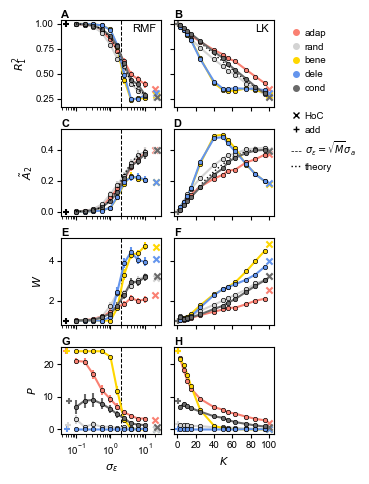

In [11]:
# FIGURE 3
fig, axs = plt.subplots(4, 2, figsize=(7/cm_to_inch, 12/cm_to_inch),
                        sharex='col', sharey='row', constrained_layout=True)

ax = axs[0,0]
for i in range (ntypes) :
    ax.scatter (sigma_es, np.mean (R2_1[:,i,:], axis=1), s=M_SIZE, color=colors[i], marker='o', edgecolor='black', linewidth=.5, zorder=10)
    ax.errorbar (sigma_es, np.mean (R2_1[:,i,:], axis=1), 1.96 * np.sqrt (np.var (R2_1[:,i,:], axis=1) / nsims), color=colors[i])

# theory
ax.plot (sigma_es, num / denom, linestyle='dotted', color='black', lw=1, zorder=20)

# HOC
for i in range (ntypes) :
    ax.scatter (sigma_es[-1] * 2+.5*i, np.mean (R2_hoc[i,:,1], axis=0),  s=ME_SIZE, color=hoc_colors[i], marker='x')

# additive
ax.scatter (sigma_es[0]*.5, R2_add[0], s=ME_SIZE, color='black', marker='+')
ax.set_ylabel ('$R^2_1$')

ax = axs[1,0]
for i in range (ntypes) :
    ax.errorbar (sigma_es, np.mean (R2_2[:,i,:], axis=1),1.96*np.sqrt ( np.var (R2_2[:,i,:], axis=1)/nsims), color=colors[i])
    ax.scatter (sigma_es, np.mean (R2_2[:,i,:], axis=1), s=M_SIZE, color=colors[i], marker='o', edgecolor='black', linewidth=.5, zorder=10)

# HOC
for i in range (ntypes) :
    ax.scatter (sigma_es[-1] * 2+.5*i, np.mean (R2_hoc[i,:,2] - R2_hoc[i,:,1], axis=0),
                s=ME_SIZE, color=hoc_colors[i], marker='x')
ax.set_ylabel (r'$\tilde A_2$')
ax.set_xscale ('log')

# theory
ax.plot (sigma_es, (2**(-M) * sigma_es**2 * math.comb (M,2)) / denom, linestyle='dotted', color='black', lw=1, zorder=20)

# additive
ax.scatter (sigma_es[0]*.5, 0, s=ME_SIZE, color='black', marker='+')

ax = axs[2,0]
for i in range (ntypes) :
    ax.errorbar (sigma_es, np.mean (nMax_t[:,i,:], axis=1), 1.96*np.sqrt (np.var (nMax_t[:,i,:], axis=1) / nsims),
                 color=colors[i])
    ax.scatter (sigma_es, np.mean (nMax_t[:,i,:], axis=1), s=M_SIZE, color=colors[i], marker='o', edgecolor='black', linewidth=.5, zorder=10)

# HOC
for i in range (ntypes) :
    ax.scatter (sigma_es[-1] * 2+.5*i, np.mean (Max_hoc_total[i,:], axis=0), s=ME_SIZE, color=hoc_colors[i], marker='x')
# additive
ax.scatter (sigma_es[0]*.5, R2_add[0], s=ME_SIZE, color='black', marker='+')

ax.set_ylabel (r'$W$')

ax = axs[3,0]
for i in range (ntypes) :
    ax.errorbar (sigma_es, np.mean (Psigma[:,i,:], axis=1), 1.96*np.sqrt (np.var (Psigma[:,i,:], axis=1)/nsims), color=colors[i])
    ax.scatter (sigma_es, np.mean (Psigma[:,i,:], axis=1), s=M_SIZE, color=colors[i], marker='o', edgecolor='black', linewidth=.5, zorder=10)

# hoc
for i in range (ntypes) :
    ax.scatter (sigma_es[-1] * 2+.5*i, np.mean (Paths_hoc[i,:], axis=0), s=ME_SIZE, color=hoc_colors[i], marker='x')

ax.set_ylabel (r'$P$')

axs[-1,0].set_xlabel (r'$\sigma_\epsilon$')
    
for i in range (4) :
    axs[i,0].axvline (np.sqrt (M*sigma_a**2), color='black', linestyle='--', linewidth=.75)

# additive
nPaths_add    = np.zeros (ntypes)
nPaths_add[0] = nPaths_add[1] = math.factorial (M)
nPaths_add[3] = (.5)**M * math.factorial (M)
nPaths_add[4] = .361 * math.factorial (M) # see supplement

for i in range (ntypes) :
    ax.scatter (sigma_es[0]*.5+.003*i, nPaths_add[i], s=ME_SIZE, color=hoc_colors[i], marker='+')

# legend
legend_handles = []

i = 0
for color in colors:
    legend_handles.append(
        Line2D( [0],[0],marker='o',color=colors[i],linestyle="None", markersize=4, markeredgewidth=1,label=scenarios[i][:4] )
    )
    i+= 1

legend_handles.append (
    Line2D( [0],[0],marker='x',color="white",linestyle="None", markersize=4, markeredgewidth=1,label='')
)
legend_handles.append (
    Line2D( [0],[0],marker='x',color="black",linestyle="None", markersize=4, markeredgewidth=1,label='HoC')
)
legend_handles.append (
    Line2D( [0],[0],marker='+',color="black",linestyle="None", markersize=4, markeredgewidth=1,label='add')
)   
legend_handles.append(
    Line2D([0],[0],color="black",linestyle="--",linewidth=.5, label=r'$\sigma_\epsilon = \sqrt{M} \sigma_a$')
)
legend_handles.append(
    Line2D([0],[0],color="black",linestyle="dotted",linewidth=1, label=r'theory')
)

#fig.legend (handles=legend_handles, loc='outside upper center',
#            ncol=5, frameon=False, bbox_to_anchor=(.59,1.1),
#            labelspacing=.5, columnspacing=.5, handletextpad=0.4)

fig.legend (handles=legend_handles, loc='right',
            ncol=1, frameon=False, bbox_to_anchor=(1.3,.8), handlelength=1,
            labelspacing=.5, columnspacing=.5, handletextpad=0.4)

# LK
add_idx = list(K_values).index(1)
sweep_idx = [i for i in range(len(K_values)) if i != add_idx]
x_hoc = p

step = 20
round_ticks = list(range(0, p + 1, step))
if round_ticks[-1] != p:
    round_ticks.append(p)

panel_specs = [
    ("R1_2", r"$R_1^2$", False),
    ("R2_2_minus_R1_2", r"$\tilde A_2$", True),
    ("localmax", r"$W$", False),
    ("paths", r"$P$", False),
]

K_theory_grid = np.arange(1, p + 1)
theory_R1 = np.array([theory_R1_and_R2minusR1(K,L_lk,M,SIGMA)[0] for K in K_theory_grid])
theory_R2minusR1 = np.array([theory_R1_and_R2minusR1(K,L_lk,M,SIGMA)[1] for K in K_theory_grid])

excluded_points = {("localmax", "rand"): [2]}

axes_top = [axs[i,1] for i in range (4)]

for ax, (metric, ylabel, is_diff) in zip(axes_top, panel_specs):
    for m in methods:
        if is_diff:
            mean, sem = diff_mean_sem(data, "R2_2", "R1_2", m)
        else:
            mean = g(data, metric, m, "mean")
            sem = g(data, metric, m, "sem")

        this_sweep_idx = [i for i in sweep_idx if K_values[i] not in excluded_points.get((metric, m), [])]

        #plot_series(ax, K_values[this_sweep_idx], mean[this_sweep_idx],
        #            CI_MULT * sem[this_sweep_idx], colordict[m])


        ax.errorbar (K_values[this_sweep_idx], mean[this_sweep_idx],
                     1.96*sem[this_sweep_idx], color=colordict[m])
        ax.scatter (K_values[this_sweep_idx], mean[this_sweep_idx], 
                    s=M_SIZE, color=colordict[m], marker='o', edgecolor='black', linewidth=.5, zorder=10)

        
        #ax.errorbar(x, y, yerr=yerr, color=color, marker="o", markersize=M_SIZE,
        #        markeredgecolor="black", markeredgewidth=MARKER_EDGEWIDTH,
        #        lw=0, elinewidth=.5, capsize=0, zorder=3)
        #ax.scatter (K_values[this_sweep_idx], mean[this_sweep_idx],
        #            color=colordict[m], lw=.5, zorder=2)

        
        add_mean = mean[add_idx]
        plot_endpoint(ax, K_values[add_idx], add_mean, colordict[m], "+")

        if is_diff:
            hoc_mean = diff_mean_sem_hoc(hoc, "R2_2", "R1_2", m)
        else:
            hoc_mean = g_hoc(hoc, metric, m, "mean")
        plot_endpoint(ax, x_hoc, hoc_mean, colordict[m], "x")


axes_top[0].plot (K_theory_grid, theory_R1, color="black", lw=1, ls="dotted", zorder=0)
axes_top[1].plot (K_theory_grid, theory_R2minusR1, color="black", lw=1, ls="dotted", zorder=0)

ct = 0
for j in range (4) :
    for i in range (2) :
        axs[j,i].set_title (string.ascii_uppercase[ct], pad=1.2, loc='left', fontweight='bold', fontsize=8)
        ct += 1

ax = axs[-1,1]
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xticklabels(np.arange(0, 101, 20))
ax.tick_params(labelbottom=True)
ax.set_xlabel (r'$K$')

ax = axs[0,0]
ax.text(0.95, 0.95, "RMF",
        transform=ax.transAxes,
        ha='right', va='top')

ax = axs[0,1]

ax.text(0.95, 0.95, "LK",
        transform=ax.transAxes,
        ha='right', va='top')

if save :
    plt.savefig (os.path.join (outputdir, 'rmf_lk_figure.pdf'),
                 bbox_inches='tight')
    plt.close ()
else : 
    plt.show ()

In [12]:
# Figure 5 for LK plot
metrics       = ['N_i', 'delta_f_i', 'N_ij', 'delta_f_ij']
scenarios_lk  = ['rand','topm','bot4','traj','cond']
zorders       = [0,1,2,10,9]
colors_lk     = ['lightgray','gold','cornflowerblue','salmon','dimgray',]
#metric_labels = [r'$\overline{\Delta B_i}$',  r'$\overline{\Delta f_i}$', 
#                 r'$\overline{\Delta B_{ij}}$', r'$\overline{\Delta f_{ij}}$']
metric_labels = [r'$\Delta B_i$',  r'$\Delta f_i$', 
                 r'$\Delta B_{ij}$', r'$\Delta f_{ij}$']

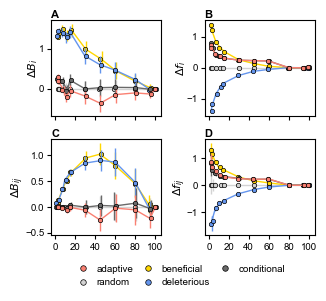

In [13]:
# Figure 5
fig, axes = plt.subplots(2, 2, figsize=(8/ cm_to_inch, 2.5), sharex=True, constrained_layout=True)

ct = 0
for met in metrics :
    ax = axes.flat[ct] 
    ct_scen = 0
    for scen in scenarios_lk :
        mean = d2[f"{met}_{scen}"] - d2[f"{met}_rand"]
        sem  = d2[f"{met}_{scen}_sem"]
        sem  = np.hypot(sem, d2[f"{met}_rand_sem"])
        ax.errorbar(K_neigh[1:] + np.random.normal (0,.5,len (K_neigh[1:])), mean[1:], 
                    yerr=1.96 * sem[1:], color=colors_lk[ct_scen], lw=1,
                    elinewidth=1,  capsize=0, label=scen,
                    zorder=zorders[ct_scen])

        ax.scatter (K_neigh[1:] + np.random.normal (0,.5,len (K_neigh[1:])), mean[1:],
                    color=colors_lk[ct_scen], s=M_SIZE, edgecolor='black', linewidth=.5, zorder=zorders[ct_scen]+1 )
        ct_scen += 1

    ax.set_xticks (np.arange (0,101,20))
    ax.set_title (string.ascii_uppercase[ct], pad=1.2, loc='left', fontweight='bold', fontsize=8)
    ax.set_ylabel (metric_labels[ct], labelpad=-1)
    
    ct += 1

    # legend
legend_handles = []
i = 0
for color in colors:
    legend_handles.append(
            Line2D( [0],[0],marker='o',color=color, linestyle="None", markersize=4, 
                    markeredgecolor='black', markeredgewidth=.5,label=scenarios[i] )
        )
    i+= 1
    
fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=(0.55, .0),   # was effectively ~1.0; lower this to move down
           ncol=3, frameon=False,
           labelspacing=.5, columnspacing=.5, handletextpad=0.4)

if save :
    plt.savefig (os.path.join (outputdir, 'lk_components.pdf'),
                 bbox_inches='tight')
    plt.close ()
else : 
    plt.show ()

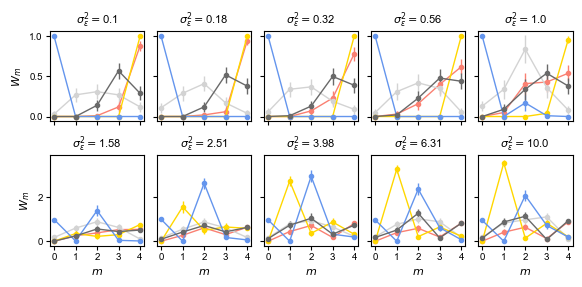

In [14]:
# Figure of local maxima in RMF as function of distance from ancestor
fig, axs = plt.subplots( 2, 5, figsize=(14.5/cm_to_inch, 7/cm_to_inch),
                         constrained_layout=True, sharex=True, sharey='row')

for j in range (len (SigmaDict)) :
    Cow = cp.deepcopy (SigmaDict[j]['nMax'])
    for i in range (len (scenarios)) :    
        axs[int (j/5), j % 5].errorbar (np.arange (0,M+1,1), np.mean (Cow[i,:,:], axis=0), 
                                        yerr=1.96 * np.sqrt (np.var (Cow[i,:,:], axis=0) / nsims),
                                        color=colors[i], marker='.', lw=1)
    axs[int (j/5), j % 5].set_title (r'$\sigma_\epsilon^2=$' + str (np.round (sigma_es[j],2)))
for i in range (2) :
    axs[i,0].set_ylabel (r'$W_m$')

for i in range (ntypes) :
    axs[1,i].set_xlabel (r'$m$')

axs[0,0].set_xticks (np.arange (0,M+1,1), np.arange (0,M+1,1))
if save :
    plt.savefig (os.path.join (outputdir, 'rmf_Wm_' + str (sigma_a) + '_' + str (nsims) + '.pdf'),
                 bbox_inches='tight')
    plt.close ()
else :
    plt.show ()

In [15]:
# get indices of the mutants we care about
X = cp.deepcopy (SigmaDict[0]['X'])

# indices of adaptive mutants
da = np.zeros (M, dtype=int)
test = np.zeros (M, dtype=int)
for i in range (M) :
    test[i] = 1
    da[i] = np.where ( np.sum (X == test, axis=1) == M )[0][0]

# one step before
dminus = np.append ([0], da[:-1])

# single mutants
d1 = np.where (np.sum (X, axis=1) == 1)[0]

# derived mutant
dM = np.where (np.sum (X, axis=1) == M)[0]
print (dM)

[15]


In [23]:
cmap = LinearSegmentedColormap.from_list(
    'maroon_salmon',
    [(0.00, 'white'),
     (0.05, 'white'),     # hold white across the lowest slice
     (0.50, 'gray'),
     (1.00, 'black')]
)
cmap.set_under('white')

start_idx = string.ascii_uppercase.index('E')
start_idx = 0

cond_idx = [x for x in range (ntypes) if scenarios[x] == 'conditional']
adap_idx = [x for x in range (ntypes) if scenarios[x] == 'adaptive']

li = 0
mi = 4
hi = len (sigma_es)-1

A = cp.deepcopy (SigmaDict[li]['A'])
E = cp.deepcopy (SigmaDict[li]['E'])
datasets = list ()
for i in range (ntypes) :
    if scenarios[i] == 'adaptive' :
        datasets.append ( (np.ndarray.flatten (A[i,:,d1] - A[i,:,0]),
                           np.ndarray.flatten (E[i,:,da]), colors[i], string.ascii_uppercase[start_idx+i]) )
    else :
        datasets.append ( (np.ndarray.flatten (A[i,:,d1] - A[i,:,0]),
                           np.ndarray.flatten (E[i,:,d1]), colors[i], string.ascii_uppercase[start_idx+i]) )

endpoints = ( A[cond_idx, :, dM] - A[i,:,0], E[cond_idx, :, dM])
endpoints_a = ( A[adap_idx, :, dM] - A[i,:,0], E[adap_idx, :, dM])


Am = cp.deepcopy (SigmaDict[mi]['A'])
Em = cp.deepcopy (SigmaDict[mi]['E'])
datasets_med = list ()
for i in range (ntypes) :
    if scenarios[i] == 'adaptive' :
        datasets_med.append ( (np.ndarray.flatten (Am[i,:,d1] - Am[i,:,0]),
                           np.ndarray.flatten (Em[i,:,da]), colors[i], string.ascii_uppercase[start_idx+i+ntypes]) )
    else :
        datasets_med.append ( (np.ndarray.flatten (Am[i,:,d1] - Am[i,:,0]),
                           np.ndarray.flatten (Em[i,:,d1]), colors[i], string.ascii_uppercase[start_idx+i+ntypes]) )

endpoints_med = (Am[cond_idx, :, dM] - Am[i,:,0], Em[cond_idx, :, dM])
endpoints_med_a = ( Am[adap_idx, :, dM] - Am[i,:,0], Em[adap_idx, :, dM])


Ah = cp.deepcopy (SigmaDict[hi]['A'])
Eh = cp.deepcopy (SigmaDict[hi]['E'])
datasets_high = list ()
for i in range (ntypes) :
    if scenarios[i] == 'adaptive' :
        datasets_high.append ( (np.ndarray.flatten (Ah[i,:,d1] - Ah[i,:,0]),
                           np.ndarray.flatten (Eh[i,:,da]), colors[i], string.ascii_uppercase[start_idx+i+ntypes]) )
    else :
        datasets_high.append ( (np.ndarray.flatten (Ah[i,:,d1] - Ah[i,:,0]),
                           np.ndarray.flatten (Eh[i,:,d1]), colors[i], string.ascii_uppercase[start_idx+i+ntypes]) )

endpoints_high = (Ah[cond_idx, :, dM] - Ah[i,:,0], Eh[cond_idx, :, dM])
endpoints_high_a = ( Ah[adap_idx, :, dM] - Ah[i,:,0], Eh[adap_idx, :, dM])

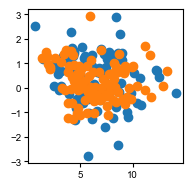

-0.18952670108731337
-0.11791903662870037


In [35]:
plt.rcParams['figure.figsize'] = (2,2)
plt.scatter (endpoints_med[0], endpoints_med[1])
plt.scatter (endpoints_med_a[0], endpoints_med_a[1])
plt.show ()

print (np.corrcoef (endpoints_med[0], endpoints_med[1])[0,1])
print (np.corrcoef (endpoints_med_a[0], endpoints_med_a[1])[0,1])

In [17]:
min_x, max_x = get_min_max_list ([datasets,datasets_med,datasets_high], 0)
min_y, max_y = get_min_max_list ([datasets,datasets_med,datasets_high], 1)

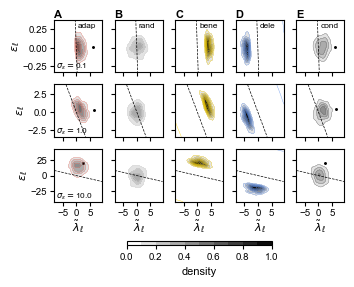

In [18]:
# 3. one subplot each, identical grid + levels + vmax
fig, axs_all = plt.subplots(3, len(datasets), figsize=(8.7/cm_to_inch, 7/cm_to_inch),
                        sharex=True, sharey='row', constrained_layout=True)

# 1. one shared grid spanning the union of all data
gridn = 200

all_y = np.concatenate([d[1] for d in datasets])
xi = np.linspace(min_x, max_x, gridn)
yi = np.linspace(all_y.min (), all_y.max(), gridn)
X, Y = np.meshgrid(xi, yi)

# 2. evaluate every layer on that same grid, then get the global max
Zs = [kde_on_grid(x, y, X, Y) for x, y, _, _ in datasets]
vmax = max(Z.max() for Z in Zs)

Zs   = [Z / vmax for Z in Zs]                 # every layer now in [0, 1]
vmax = 1.0                                     # peak is 1.0 by construction

target_bins = 15
step = nice_step(vmax / target_bins)          # round step size
top  = np.ceil(vmax / step) * step            # extend range up to a multiple
levels = np.arange(0, top + step / 2, step)   # 0, step, 2*step, ... , top

ct = 0
axs = axs_all[0,:]
for ax, Z, (_, _, color, label) in zip(axs, Zs, datasets):
    cf = ax.contourf(X, Y, Z, levels=levels, vmin=0, vmax=top, cmap=cmap)
    ax.contour(X, Y, Z, levels=levels, colors=color, linewidths=0.25)
    ax.set_title(label, pad=.5, loc='left', fontweight='bold')
    ax.axline((0, 0), slope=-1, color='black', linestyle='--', linewidth=.5, label=r'$\epsilon = 2\lambda x_\ell$')
    ax.text(
        0.5, 0.95,                    # x, y coordinates in axes fraction
        scenarios[ct][:4],             # The text string
        transform=ax.transAxes,        # Use axis coordinates instead of data coordinates
        verticalalignment='top',       # Align the top of the text box to the y-coordinate
        horizontalalignment='left',    # Align the left of the text box to the x-coordinate
        fontsize=6                    # Optional styling
    )
    ct += 1
ax.scatter (np.mean (endpoints[0]), np.mean (endpoints[1]), marker='.', color='black', s=5)
axs_all[0,0].scatter (np.mean (endpoints_a[0]), np.mean (endpoints_a[1]), marker='.', color='black', s=5)

axs_all[0,0].text(
    0.05, 0.2,                    # x, y coordinates in axes fraction
    r'$\sigma_\epsilon = $' + str (np.round (sigma_es[li], 1)),              # The text string
    transform=axs_all[0,0].transAxes,        # Use axis coordinates instead of data coordinates
    verticalalignment='top',       # Align the top of the text box to the y-coordinate
    horizontalalignment='left',    # Align the left of the text box to the x-coordinate
    fontsize=6                    # Optional styling
)


# MEDIUM
all_y = np.concatenate([d[1] for d in datasets_med])
yi = np.linspace(all_y.min(), all_y.max(), gridn)
X, Y = np.meshgrid(xi, yi)

# 2. evaluate every layer on that same grid, then get the global max
Zs = [kde_on_grid(x, y, X, Y) for x, y, _, _ in datasets_med]
vmax = max(Z.max() for Z in Zs)

Zs   = [Z / vmax for Z in Zs]                 # every layer now in [0, 1

axs = axs_all[1,:]
for ax, Z, (_, _, color, label) in zip(axs, Zs, datasets_med):
    cf = ax.contourf(X, Y, Z, levels=levels, vmin=0, vmax=top, cmap=cmap)
    ax.contour(X, Y, Z, levels=levels, colors=color, linewidths=0.25)
    ax.axline((0, 0), slope=-1, color='black', linestyle='--', linewidth=.5, label=r'$\epsilon = 2\lambda x_\ell$')

ax.scatter (np.mean (endpoints_med[0]), np.mean (endpoints_med[1]), marker='.', color='black', s=5)
axs_all[1,0].scatter (np.mean (endpoints_med_a[0]), np.mean (endpoints_med_a[1]), marker='.', color='black', s=5)

axs_all[1,0].text(
    0.05, 0.2,                    # x, y coordinates in axes fraction
    r'$\sigma_\epsilon = $' + str (np.round (sigma_es[mi], 1)),              # The text string
    transform=axs_all[1,0].transAxes,        # Use axis coordinates instead of data coordinates
    verticalalignment='top',       # Align the top of the text box to the y-coordinate
    horizontalalignment='left',    # Align the left of the text box to the x-coordinate
    fontsize=6                    # Optional styling
)



# high
all_y = np.concatenate([d[1] for d in datasets_high])
yi = np.linspace(all_y.min(), all_y.max(), gridn)
X, Y = np.meshgrid(xi, yi)

# 2. evaluate every layer on that same grid, then get the global max
Zs = [kde_on_grid(x, y, X, Y) for x, y, _, _ in datasets_high]
vmax = max(Z.max() for Z in Zs)

Zs   = [Z / vmax for Z in Zs]                 # every layer now in [0, 1]
vmax = 1.0                                     # peak is 1.0 by construction

step = nice_step(vmax / target_bins)          # round step size
top  = np.ceil(vmax / step) * step            # extend range up to a multiple
levels = np.arange(0, top + step / 2, step)   # 0, step, 2*step, ... , top

axs = axs_all[2,:]
for ax, Z, (_, _, color, label) in zip(axs, Zs, datasets_high):
    cfh = ax.contourf(X, Y, Z, levels=levels, vmin=0, vmax=top, cmap=cmap)
    ax.contour(X, Y, Z, levels=levels, colors=color, linewidths=0.25)
    ax.axline((0, 0), slope=-1, color='black', linestyle='--', linewidth=.5, label=r'$\epsilon = 2\lambda x_\ell$')

    ax.set_xlabel (r'$\tilde \lambda_\ell$', labelpad=.5)

ax.scatter (np.mean (endpoints_high[0]), np.mean (endpoints_high[1]), marker='.', color='black', s=5)
axs_all[2,0].scatter (np.mean (endpoints_high_a[0]), np.mean (endpoints_high_a[1]), marker='.', color='black', s=5)

axs_all[2,0].text(
    0.05, 0.2,                    # x, y coordinates in axes fraction
    r'$\sigma_\epsilon = $' + str (np.round (sigma_es[hi], 1)),              # The text string
    transform=axs_all[2,0].transAxes,        # Use axis coordinates instead of data coordinates
    verticalalignment='top',       # Align the top of the text box to the y-coordinate
    horizontalalignment='left',    # Align the left of the text box to the x-coordinate
    fontsize=6                    # Optional styling
)

fig.colorbar(cfh, ax=axs, label='density', location='bottom', shrink=.5, aspect=30, pad=0.1)   # one shared bar

for i in range (3) :
    axs_all[i,0].set_ylabel (r'$\epsilon_\ell$', labelpad=.5)

if save :
    plt.savefig (os.path.join (outputdir, 'densities_three.pdf'), bbox_inches='tight')
    plt.close ()
else :
    plt.show()

In [19]:
# plot R2 statistics for a bunch of different M valuess
Mvals = np.arange (2,21,1)

sigmas_M = [.1,1,10]

nmax = int (np.min (Mvals))
R2_random = np.zeros ( (nmax, len (Mvals), len (sigmas_M)) )
for se in range (len (sigmas_M)) :
    ct = 0
    for m in Mvals :
        for i in range (1, nmax+1) :
            R2_random[i-1,ct,se] = Atildem (i, m, sigma_a=1, sigma_e=sigmas_M[se])
        ct += 1

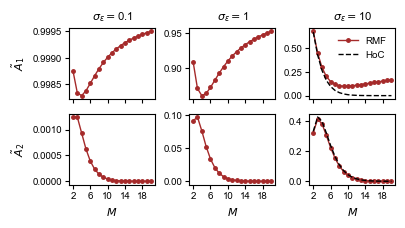

In [20]:
fig, axs = plt.subplots (2,3, figsize=(10/cm_to_inch, 5.5/cm_to_inch),
                         sharey=False, sharex=True, constrained_layout=True)

for se in range (len (sigmas_M)) :
    ax = axs[0,se]
    ax.plot (Mvals, R2_random[0,:,se], marker='.', markersize=5, lw=1, color='brown', label='RMF')
    ax.set_title (r'$\sigma_\epsilon = $' + str (sigmas_M[se]))

    if se == len (sigmas_M) - 1 :
        ax.plot ( Mvals, Mvals / (2**Mvals - 1), color='black', linestyle='--', lw=1, label='HoC')
        ax.legend (frameon=False)
    if se == 0 :
        ax.set_ylabel (r'$\tilde A_1$')
    
    ax = axs[1,se]
    ax.plot (Mvals, R2_random[1,:,se], marker='.', markersize=5, lw=1, color='brown')

    if se == 0 :
        ax.set_ylabel (r'$\tilde A_2$')

    if se == len (sigmas_M) - 1 :
        ax.plot ( Mvals, np.array ([math.comb (i,2) for i in Mvals]) / (2**Mvals - 1), color='black', linestyle='--', lw=1, label='HoC')

    ax.set_xticks (Mvals[np.arange (0,21-2,4)], Mvals[np.arange (0,21-2,4)])
    ax.set_xlabel (r'$M$')


if save :
    plt.savefig (os.path.join (outputdir, r'RMF_M_random_' + str (sigma_a) + '.pdf'),
                 bbox_inches='tight')
    plt.close ()
else :
    plt.show ()

In [21]:
for i in range (len (sigma_es)) :
    print (np.mean (R2_1[i,:,:], axis=1))

[0.99656772 0.997514   0.9996298  0.99960671 0.99818362]
[0.99048424 0.99150759 0.99870546 0.99867558 0.99375209]
[0.973386   0.97078568 0.99576161 0.99571938 0.98185549]
[0.92771053 0.91182331 0.98402386 0.98514707 0.94802393]
[0.84460112 0.78914084 0.94431692 0.93957688 0.87690071]
[0.73170596 0.65164903 0.76787263 0.78786788 0.77646421]
[0.62905925 0.5791517  0.44233603 0.49035963 0.60586756]
[0.49463874 0.40233304 0.2386755  0.24704822 0.43975274]
[0.44595558 0.32855072 0.25500686 0.25234329 0.39391939]
[0.39668534 0.27277262 0.25641981 0.28340177 0.29240455]


In [22]:
print (R2_1.shape)

for i in range (len (sigma_es)) :
    values = np.ndarray.flatten( R2_1[i,:,:], order='C')                      # stack columns
    labels = np.repeat(scenarios, R2_1[i,:,:].shape[1])        # matching group labels
    tukey  = pairwise_tukeyhsd(values, labels, alpha=0.01)

    print (tukey)

(10, 5, 100)
     Multiple Comparison of Means - Tukey HSD, FWER=0.01      
   group1      group2   meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
   adaptive  beneficial   0.0031    0.0  0.0014  0.0047   True
   adaptive conditional   0.0016 0.0116    -0.0  0.0033  False
   adaptive deleterious    0.003    0.0  0.0014  0.0047   True
   adaptive      random   0.0009 0.3243 -0.0007  0.0026  False
 beneficial conditional  -0.0014 0.0329 -0.0031  0.0002  False
 beneficial deleterious     -0.0    1.0 -0.0017  0.0016  False
 beneficial      random  -0.0021 0.0003 -0.0038 -0.0005   True
conditional deleterious   0.0014 0.0375 -0.0002  0.0031  False
conditional      random  -0.0007 0.6681 -0.0023   0.001  False
deleterious      random  -0.0021 0.0003 -0.0037 -0.0005   True
--------------------------------------------------------------
     Multiple Comparison of Means - Tukey HSD, FWER=0.01      
   group1      group2   meandiff p-adj   l